In [1]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

import numpy as np
import os
import sys

In [2]:
print("Current working directory", os.getcwd() )
print("Directory contents:", os.listdir())

os.chdir("/Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project")
print("Current working directory", os.getcwd() )

Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/training
Directory contents: ['train_adversatiral.py', '__pycache__', 'train_minimal.py', 'train_mlp.ipynb', 'train_standard.py', 'train_minimal.ipynb']
Current working directory /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from models.eegnet import EEGNet
from models.eenMLP import EEGMLP
from models.deepconvnet import DeepConvNet
from utils.loaders import get_dataloader
from utils.checks import check_shapes
from utils.preprocessing import preprocess_all_subjects
from utils.standardise_data import standardize_eeg_data
from utils.augment_eeg_data import augment_eeg_data


In [4]:
# ---------- Config ----------
subject_id = 8
batch_size = 32
epochs =150
lr = 0.00015
device = torch.device("mps" if torch.backends.mps.is_available() else 'cpu')
# "mps" if torch.backends.mps.is_available() else

In [5]:
# ----------Re run the Preprocessing --------
preprocess_all_subjects(subject_ids=[1, 2, 3, 4, 5, 6, 7, 8, 9])

# ---------- Load Data ----------
dataset = get_dataloader(subject_ids=[1, 2, 3, 4, 5, 6, 7, 8, 9], return_dataset=True)
X, y = dataset.X, dataset.y
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"X dtype: {X.dtype}, y dtype: {y.dtype}")
print(f"y unique: {np.unique(y)}")
check_shapes(X, y)

# Ensure y is a NumPy array
y = np.array(y)

preprocessing subject 1 .....
Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated


...

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Selected EEG channels: 22
['EEG-Fz', 'EEG-C3', 'EEG-Cz', 'EEG-C4', 'EEG-Pz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-6', 'EEG-7', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-15', 'EEG-16']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated


[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    1.4s finished


SSP projectors applied...
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event dict: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Not setting metadata
288 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 288 events and 1001 original time points ...
0 bad epochs dropped
Preprocessing complete
X shape: (2592, 22, 1001), y shape: (2592,)
X dtype: float64, y dtype: int64
y unique: [0 1 2 3]


In [6]:
# Filter out any invalid samples (e.g., negative class labels)
valid_mask = y >= 0
X = X[valid_mask]
y = y[valid_mask]

# Debug: Check what labels look like
print("Original labels:", np.unique(y), "min:", y.min(), "max:", y.max())

# Remap labels to start from 0
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.vectorize(label_map.get)(y)

print("Cleaned labels:", np.unique(y), "min:", y.min(), "max:", y.max())

X = np.expand_dims(X, axis=1)  # (samples, 22, 1001) → (samples, 1, 22, 1001)
print(X.shape)

Original labels: [0 1 2 3] min: 0 max: 3
Cleaned labels: [0 1 2 3] min: 0 max: 3
(2592, 1, 22, 1001)


In [13]:
def model_run(model, X, k_fold = False):
    if k_fold:
        # Add this cell AFTER your data loading but BEFORE your current training
        from utils.k_fold import k_fold_cross_validation
        from models.eenMLP import EEGMLP  # or whatever your model import is
        
        print(f"X shape: {X.shape}")
        print(f"y unique values: {np.unique(y)}")

        # Define a function that creates your model
        def create_model():
            return model(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)

        # Run k-fold instead of regular training
        print("Running K-Fold Cross-Validation...")
        cv_results = k_fold_cross_validation(
            X=X,
            y=y, 
            model_class=create_model,
            k_folds=2,
            epochs=30,
            batch_size=32,
            device=device
        )

        # Print summary
        print(f"\nK-Fold Results: {cv_results['mean_accuracy']:.4f} ± {cv_results['std_accuracy']:.4f}")
        return cv_results
    else:
        X = X.squeeze(1)

        # ------------- Train, val and test split -------
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

        # standardise data
        X_train, X_val, X_test, scaler = standardize_eeg_data(X_train, X_val, X_test)
        
        X_train = np.expand_dims(X_train, axis=1)
        X_val = np.expand_dims(X_val, axis=1)
        X_test = np.expand_dims(X_test, axis=1)

        # Toy dataset
        X_small, y_small = [], []
        for cls in range(4):
            idx = np.where(y == cls)[0][:30]
            X_small.append(X[idx])
            y_small.append(y[idx])

        X_small = np.concatenate(X_small, axis=0)
        y_small = np.concatenate(y_small, axis=0)
        
        assert X_train.shape[1] == 1, "Expected dummy input channel dimension (1)"
        assert X_train.shape[2] == 22, "Expected 22 EEG channels"
        assert X_train.shape[3] == 1001, "Expected 1001 time samples"
        
        # Return the variables you need
        return {
            'X_train': X_train,
            'X_val': X_val, 
            'X_test': X_test,
            'y_train': y_train,
            'y_val': y_val,
            'y_test': y_test,
            'X_small': X_small,
            'y_small': y_small,
            'scaler': scaler
        }
    

In [14]:
cv_results = model_run(EEGNet, X, k_fold=False)

## Next we plot the K-Folds visualisations 

DETAILED K-FOLD CROSS-VALIDATION RESULTS

📊 FOLD-BY-FOLD RESULTS:
   Fold 1: 0.4155 (41.55%)
   Fold 2: 0.3924 (39.24%)
   Fold 3: 0.4132 (41.32%)

📈 SUMMARY STATISTICS:
   Mean Accuracy: 0.4070 ± 0.0104
   Best Fold:     0.4155
   Worst Fold:    0.3924
   Range:         0.0231

🎯 PERFORMANCE ASSESSMENT:
   Coefficient of Variation: 2.56%
   Model Stability: Very Stable
   95% Confidence Interval: [0.3866, 0.4274]

🚀 BASELINE COMPARISON:
   Random Chance: 0.2500 (25%)
   Your Model:    0.4070 (40.70%)
   Improvement:   +62.8%
   Performance Level: Fair
Figure saved to my_kfold_results.png


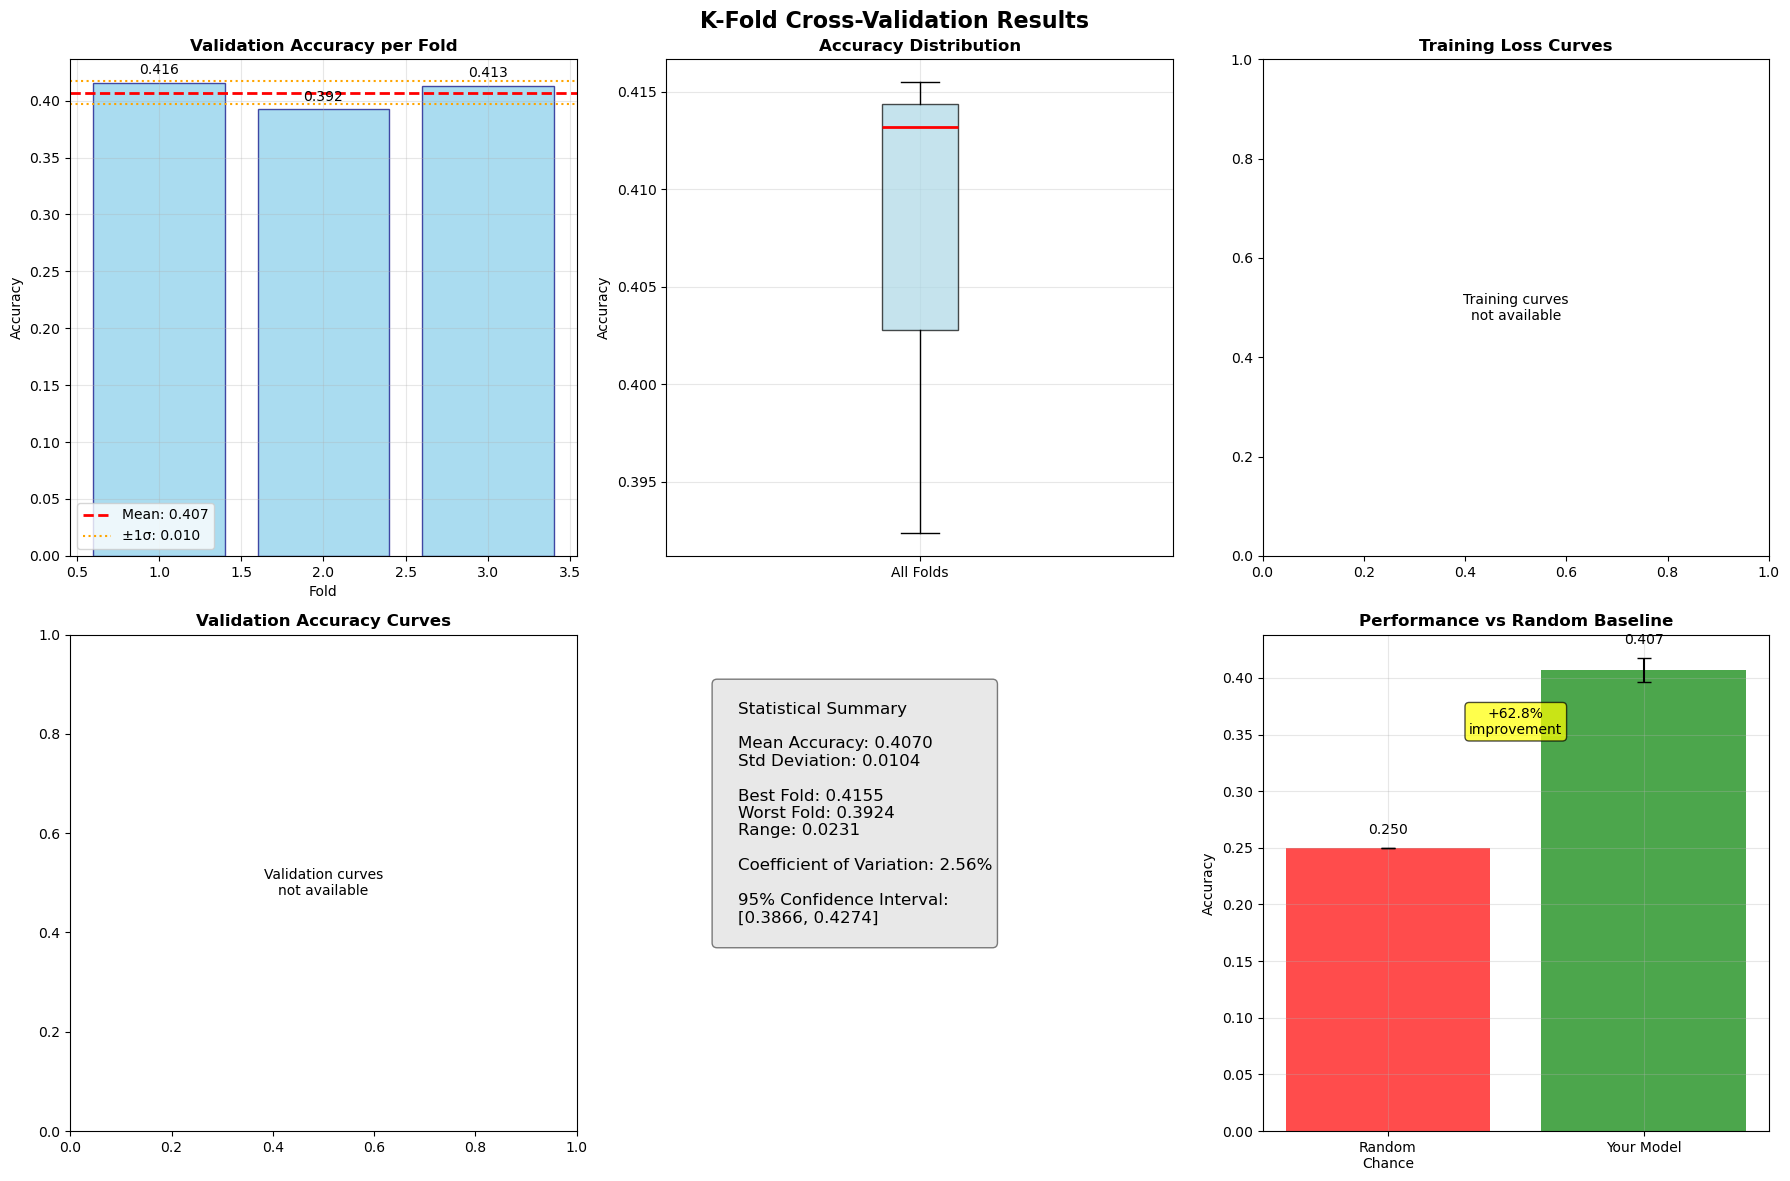

/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/utils/kfold_viz.py:162: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*[[acc] for acc in fold_accuracies])


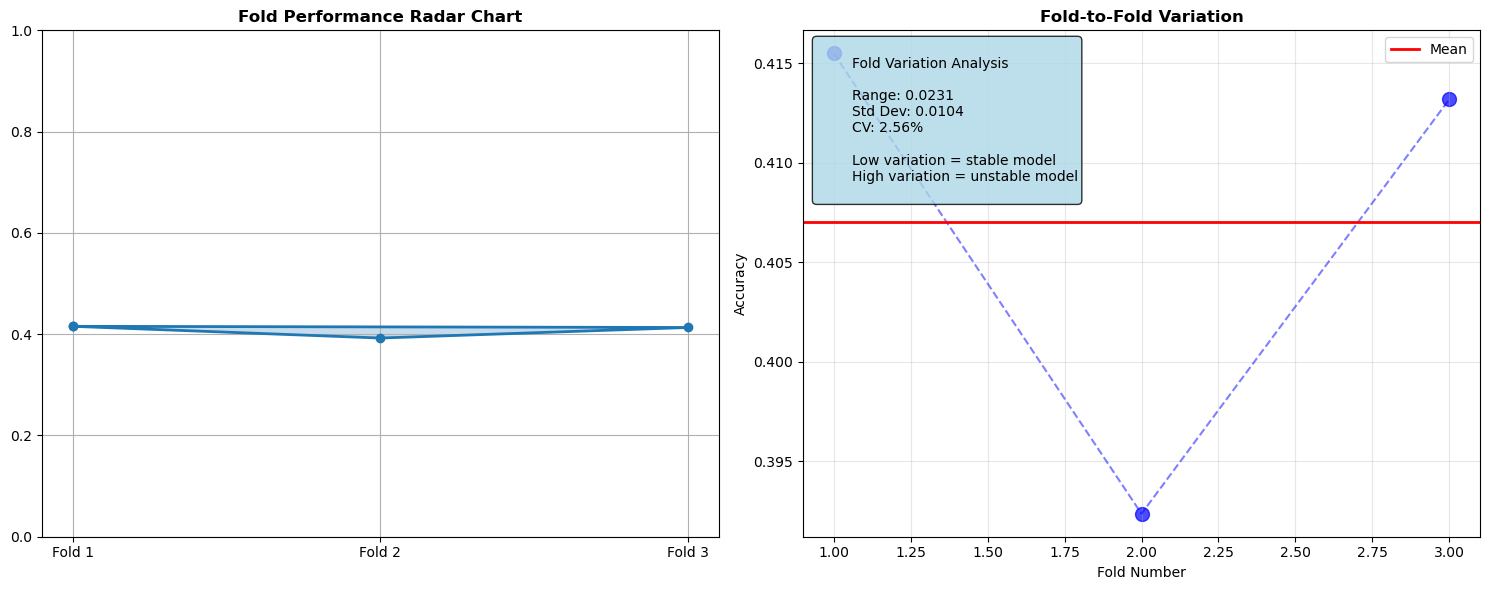

In [14]:
# Import the visualization functions (save the artifact as kfold_viz.py)
from utils.kfold_viz import plot_kfold_results, plot_fold_comparison, print_detailed_results

# When your k-fold finishes, run these:
print_detailed_results(cv_results)
plot_kfold_results(cv_results, save_path='my_kfold_results.png')
plot_fold_comparison(cv_results)

In [16]:
X_train = dcv_results['X_train']
X_val = dcv_results['X_val']
X_test = dcv_results['X_test']
X_small = dcv_results['X_small']
y_train = dcv_results['y_train']
y_val = dcv_results['y_val']
y_test = dcv_results['y_test']
y_small = dcv_results['y_small']

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# standardise data
# X_train, X_val, X_test, scaler = standardize_eeg_data(X_train, X_val, X_test)

# X_train = np.expand_dims(X_train, axis=1)
# X_val = np.expand_dims(X_val, axis=1)
# X_test = np.expand_dims(X_test, axis=1)

# Toy dataset
X_small, y_small = [], []
for cls in range(4):
    idx = np.where(y == cls)[0][:30]
    X_small.append(X[idx])
    y_small.append(y[idx])

X_small = np.concatenate(X_small, axis=0)
y_small = np.concatenate(y_small, axis=0)

print(X_train.shape)

(1555, 1, 22, 1001)


In [8]:
# wrap in Dataloader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)





In [9]:
# ---------- Model Setup for EEGNet ----------
model = EEGNet(num_classes=len(torch.unique(torch.tensor(y))), channels=X.shape[2], samples=X.shape[3] ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5, min_lr=1e-6)


for batch_X, batch_y in train_loader:
    print(f"Batch dtype: {batch_X.dtype}")
    print(f"Model weight dtype: {next(model.parameters()).dtype}")
    break


Batch dtype: torch.float32
Model weight dtype: torch.float32


In [10]:
train_losses = []
val_accuracies = []
best_val_acc = 0
patience_counter = 0
patience = 40

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # print(batch_X.shape)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
    
        # randomly augment data
        if np.random.random() > 0.5:  # 50% chance
            batch_X = augment_eeg_data(batch_X.cpu().numpy())
            batch_X = torch.tensor(batch_X, dtype=torch.float32).to(device) 
            
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
           batch_X, batch_y = batch_X.to(device), batch_y.to(device) 
           outputs = model(batch_X)
           _, predicted = torch.max(outputs.data, 1)
           total += batch_y.size(0)
           correct += (predicted == batch_y).sum().item()
    
    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)
    
    # 3. SCHEDULER STEP (after validation)
    scheduler.step(val_accuracy) 
    
    # 4. EARLY STOPPING CHECK
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        patience_counter = 0
        torch.save(model.state_dict(), 'best_eegnet_model.pth')
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_loss:.4f} - Val Acc: {val_accuracy:.4f} - LR: {current_lr:.6f}")

print("✅ Training complete.")

Epoch [1/150] - Loss: 1.4029 - Val Acc: 0.2510 - LR: 0.000150
Epoch [2/150] - Loss: 1.3857 - Val Acc: 0.2510 - LR: 0.000150
Epoch [3/150] - Loss: 1.3840 - Val Acc: 0.2510 - LR: 0.000150
Epoch [4/150] - Loss: 1.3764 - Val Acc: 0.2510 - LR: 0.000150
Epoch [5/150] - Loss: 1.3771 - Val Acc: 0.2510 - LR: 0.000150
Epoch [6/150] - Loss: 1.3721 - Val Acc: 0.2510 - LR: 0.000150
Epoch [7/150] - Loss: 1.3682 - Val Acc: 0.2510 - LR: 0.000150
Epoch [8/150] - Loss: 1.3675 - Val Acc: 0.2510 - LR: 0.000150
Epoch [9/150] - Loss: 1.3636 - Val Acc: 0.2510 - LR: 0.000150
Epoch [10/150] - Loss: 1.3633 - Val Acc: 0.2510 - LR: 0.000150
Epoch [11/150] - Loss: 1.3507 - Val Acc: 0.2510 - LR: 0.000150
Epoch [12/150] - Loss: 1.3500 - Val Acc: 0.2510 - LR: 0.000150
Epoch [13/150] - Loss: 1.3372 - Val Acc: 0.2510 - LR: 0.000150
Epoch [14/150] - Loss: 1.3612 - Val Acc: 0.2510 - LR: 0.000150
Epoch [15/150] - Loss: 1.3350 - Val Acc: 0.2510 - LR: 0.000150
Epoch [16/150] - Loss: 1.3417 - Val Acc: 0.2510 - LR: 0.000150
E

In [18]:
model.load_state_dict(torch.load('best_eegnet_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:  # Same val_loader
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

final_check_acc = correct / total
print(f"Final check accuracy: {final_check_acc:.4f}")


/var/folders/lh/djcqdsjd0fdbmg090v1g_mwh0000gn/T/ipykernel_40605/442427724.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_eegnet_

Final check accuracy: 0.4836


In [19]:

print("Prediction distribution:", np.bincount(all_preds))
print(outputs[:5])  # see if they're all biased to class 0
probs = torch.softmax(outputs, dim=1)
print(probs[0])  # e.g., tensor([0.99, 0.002, 0.002, 0.001])


print("\n🧾 Classification Report:")
print(classification_report(all_labels, all_preds))

print("\n📊 Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

NameError: name 'all_preds' is not defined

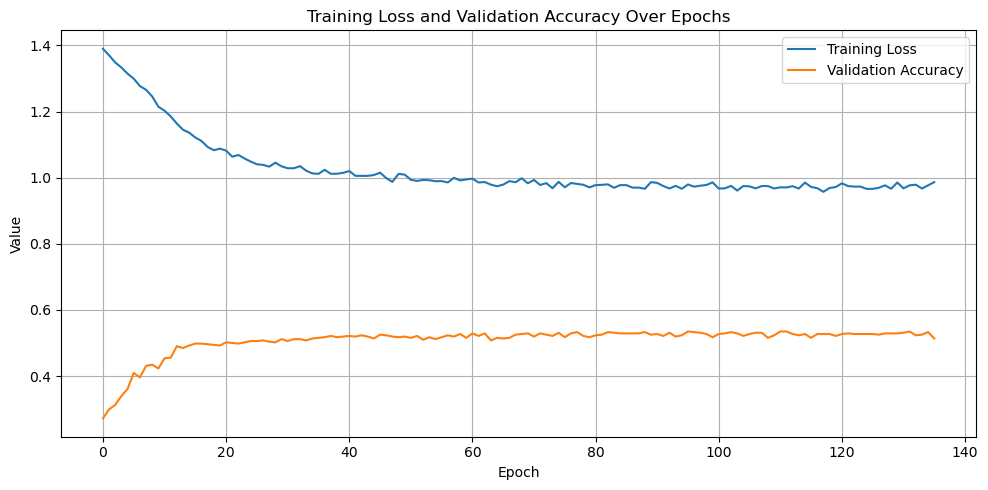

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training Loss and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/training_loss_val_accuracy.png")
plt.show()


##Observation 
This is the result of Overfittiing, Much like what Dr Zhang had suggested 
Likely that models are too large.


In [ ]:
# print state dict of model 
print("Model's state_dict: ")
for param in model.state_dict():
    print(param, '\t', model.state_dict()[param].size()) 



In [ ]:
# Print optimizer's state_dict
print("Optimizer's state_dict:")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

In [ ]:
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model state dict (this is the recommended way)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'accuracy': val_accuracy,
    'loss': loss
}, 'models/eegnet_checkpoint.pth')

In [ ]:
# plotting the activation under a certain threshold given a specific layer. 

activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

# Register hook to a specific layer (e.g., model.features[0])
hook = model.firstconv.register_forward_hook(hook_fn)

# Forward pass on a batch
model.eval()
with torch.no_grad():
    _ = model(batch_X)

# Remove hook
hook.remove()


acts = activations[0].numpy()  # Shape: (batch_size, channels, H, W)
print("Activation shape:", acts.shape)


# Convert to NumPy
acts = activations[0].numpy()  # shape: (batch_size, channels, H, W)

# Aggregate (e.g., mean over spatial dimensions and batch)
mean_acts = acts.mean(axis=(0, 2, 3))

# Plot neurons below a threshold
threshold = 0.0015
low_activating = mean_acts < threshold

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(range(len(mean_acts)), mean_acts, color=["red" if low else "blue" for low in low_activating])
plt.axhline(y=threshold, color="gray", linestyle="--")
plt.title("Neuron Activations (Red = Below Threshold)")
plt.xlabel("Neuron Index")
plt.ylabel("Mean Activation")
plt.tight_layout()
plt.show()


In [ ]:
# Registering the hooks for ease of use 

def save_hook(name):
    def hook(module, input, output):
        print(f"Captured {name} with shape {output.shape}")
        activations[name] = output.detach().cpu()
    return hook

activations = {}

# Register hooks
model.firstconv.register_forward_hook(save_hook("firstconv"))
model.depthwiseConv.register_forward_hook(save_hook("depthwise"))
model.separableConv.register_forward_hook(save_hook("separable"))


In [ ]:
model.eval()
batch_X, batch_y = next(iter(train_loader))
batch_X = batch_X.to(device)

with torch.no_grad():
    outputs = model(batch_X)


In [ ]:
    
# plotting the first five channels of the layers in our eegnet. for each layer/ 

# Example: plot first 5 channels from 'firstconv'
act = activations['depthwise'][0]  # shape: (channels, 1, time)

fig, axs = plt.subplots(5, 1, figsize=(12, 8))
for i in range(5):
    axs[i].plot(act[i][0])  # [0] to remove singleton spatial dim
    axs[i].set_title(f'Activation Channel {i}')
plt.tight_layout()
plt.show()



In [ ]:
def plot_activation(activation, layer_name, threshold=None):
    """
    activation: torch.Tensor (batch_size, channels, height, width)
    layer_name: str
    threshold: float or None (set a cutoff if you want)
    """
    # Take first batch item
    act = activation[0]
    # Take mean across time (height dimension) if needed
    mean_act = act.mean(dim=-1)  # shape: (channels, feature maps)

    plt.figure(figsize=(12,4))
    for i, ch in enumerate(mean_act):
        if threshold is None or ch.max() > threshold:
            plt.plot(ch.numpy(), label=f"channel {i}")
    plt.title(f"Activations from {layer_name}")
    plt.xlabel("feature map dimension")
    plt.ylabel("mean activation")
    plt.legend()
    plt.show()


In [ ]:
plot_activation(model.activations['firstconv'], layer_name="firstconv", threshold=0.001)


In [ ]:
acts = model.activations['firstconv']  # (N, 16, 22, something)
labels = batch_y.numpy()

for cls in np.unique(labels):
    idxs = np.where(labels == cls)[0]
    mean_act = acts[idxs].mean(dim=0)  # average over samples of that class
    # plot a filter heatmap for the first filter:
    plt.imshow(mean_act[6], aspect="auto", cmap="hot")
    plt.title(f"Class {cls} - Filter 15")
    plt.colorbar()
    plt.show()


In [ ]:
# ================
# CLASS 0 FILTER PLOTS
# ================
model.eval()

# use the same data as training (or you can use X_val if you have it)
class_idx = 0

# Filter samples for class 0
X_class0 = X[y == class_idx]
X_class0 = torch.tensor(X_class0, dtype=torch.float32).unsqueeze(1).to(device)
# shape [N_samples_class0, 1, 22, 1001]

# pass through first conv layer only
with torch.no_grad():
    first_layer = model.firstconv
    activations = first_layer(X_class0)
    # shape [N_samples_class0, n_filters, 22, time]

# take the mean over the samples
mean_activations = activations.mean(dim=0)  # shape [n_filters, 22, time]

# loop through each filter
for i in range(mean_activations.shape[0]):
    plt.figure(figsize=(12,6))
    plt.imshow(mean_activations[i].cpu(), 
               aspect='auto', 
               cmap='hot')
    plt.colorbar()
    plt.title(f"Class 0 - Filter {i}")
    plt.xlabel("Time")
    plt.ylabel("Channel")
    plt.tight_layout()
    plt.close()


In [ ]:

n_filters = mean_activations.shape[0]

# calculate rows/cols to plot in a square grid
n_cols = 4
n_rows = (n_filters + n_cols - 1) // n_cols

plt.figure(figsize=(4*n_cols, 3*n_rows))

for i in range(n_filters):
    ax = plt.subplot(n_rows, n_cols, i+1)
    img = ax.imshow(mean_activations[i].cpu(), aspect='auto', cmap='hot')
    ax.set_title(f"Filter {i}")
    plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel("Time")
    ax.set_ylabel("Channel")

plt.suptitle("Class 0 Mean Activations Across All Filters")
plt.tight_layout()
plt.savefig("results/class0_all_filters.png")
plt.show()


In [ ]:
import torch

model.eval()

# get a sample (say, 1 
# trial)
sample_X = torch.tensor(X_val[0:1], dtype=torch.float32).to(device)
sample_X.requires_grad = True  # key step

output = model(sample_X)
predicted_class = output.argmax(dim=1)

# if you want saliency for predicted class:
score = output[0, predicted_class]
score.backward()

# saliency is the absolute gradient
saliency = sample_X.grad.detach().abs().cpu().numpy()[0]

print(saliency.shape)  # should be (1, channels, time)

# plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(saliency[0], aspect='auto', cmap='hot')
plt.colorbar(label="Saliency")
plt.xlabel("Time samples")
plt.ylabel("EEG channels")
plt.title(f"Saliency map for class {predicted_class.item()}")
plt.show()


In [26]:
# Test model creation
test_model = EEGNet(num_classes=4, channels=22, samples=1001)
test_input = torch.randn(1, 1, 22, 1001)

try:
    output = test_model(test_input)
    print(f"✅ DeepConvNet works! Output shape: {output.shape}")
    print(f"Model has {sum(p.numel() for p in test_model.parameters())} parameters")
except Exception as e:
    print(f"❌ DeepConvNet error: {e}")

✅ DeepConvNet works! Output shape: torch.Size([1, 4])
Model has 21012 parameters
